## Reproducibility + Environment

In [1]:
# ─────────────────────────────────────────────
# Reproducibility controls
# ─────────────────────────────────────────────
import random
import os
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed:", SEED)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Seed: 42
Torch version: 2.7.1+cu118
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## Imports

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

from datasets import Dataset
import logging

print("All imports successful.")

C:\Users\Chamikara Pasquel\anaconda3\envs\medical_ai\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0405 20:56:31.431000 25928 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


All imports successful.


## Logging Setup

In [3]:
logging.basicConfig(
    filename="training.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)
logging.info("Pipeline started")
print("Logging configured → training.log")

Logging configured → training.log


##  Hyperparameters


In [4]:
INPUT_FILE          = "processed_clinical_data.csv"
MODEL_NAME          = "distilbert-base-uncased"
OUTPUT_DIR          = "./zolex_disease_model_v2"

# ── Data ──────────────────────────────────────────

# Classes with <20 samples cannot be learned reliably 
MIN_SAMPLES_PER_CLASS = 20

# ── Tokenization ──────────────────────────────────
MAX_LENGTH          = 128

# ── Training ──────────────────────────────────────
EPOCHS              = 10         
BATCH_SIZE          = 16         
LEARNING_RATE       = 1e-5       
WEIGHT_DECAY        = 0.01
WARMUP_STEPS        = 500         #  LR warmup prevents early instability

# ── Focal Loss ────────────────────────────────────
FOCAL_GAMMA         = 2.0

# ── Label Smoothing ───────────────────────────────
LABEL_SMOOTHING     = 0.1

print(f"Config loaded. MIN_SAMPLES={MIN_SAMPLES_PER_CLASS}, MAX_LEN={MAX_LENGTH}, "
      f"BS={BATCH_SIZE}, LR={LEARNING_RATE}, gamma={FOCAL_GAMMA}")

Config loaded. MIN_SAMPLES=20, MAX_LEN=128, BS=16, LR=1e-05, gamma=2.0


## Load & Inspect Data

In [5]:
df = pd.read_csv(INPUT_FILE)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nLabel distribution (top 10):")
print(df['label'].value_counts().head(10))
print("\nLabel distribution (bottom 10):")
print(df['label'].value_counts().tail(10))
df.head()

Dataset shape: (246945, 2)
Columns: ['text', 'label']

Label distribution (top 10):
label
cystitis                          1219
vulvodynia                        1218
nose disorder                     1218
complex regional pain syndrome    1217
spondylosis                       1216
hypoglycemia                      1215
peripheral nerve disorder         1215
esophagitis                       1215
vaginal cyst                      1215
conjunctivitis due to allergy     1215
Name: count, dtype: int64

Label distribution (bottom 10):
label
diabetes                        1
myocarditis                     1
open wound of the chest         1
chronic ulcer                   1
huntington disease              1
typhoid fever                   1
rocky mountain spotted fever    1
open wound of the knee          1
hypergammaglobulinemia          1
open wound due to trauma        1
Name: count, dtype: int64


,text,label
0,"Patient has anxiety and nervousness, shortness...",panic disorder
1,"Patient has shortness of breath, depressive or...",panic disorder
2,"Patient has anxiety and nervousness, depressio...",panic disorder
3,"Patient has anxiety and nervousness, depressiv...",panic disorder
4,"Patient has anxiety and nervousness, depressio...",panic disorder


## Filter Rare Classes
With 20 samples minimum, every class has enough examples for both train and val splits.

In [6]:
label_counts = df['label'].value_counts()

print(f"Before filtering: {df.shape[0]} rows, {df['label'].nunique()} classes")
print(f"\nClasses with < {MIN_SAMPLES_PER_CLASS} samples: "
      f"{(label_counts < MIN_SAMPLES_PER_CLASS).sum()}")

valid_labels = label_counts[label_counts >= MIN_SAMPLES_PER_CLASS].index
df = df[df['label'].isin(valid_labels)].reset_index(drop=True)

print(f"After filtering:  {df.shape[0]} rows, {df['label'].nunique()} classes")

# Show class size distribution
remaining_counts = df['label'].value_counts()
print(f"\nClass size stats:")
print(f"  Min samples: {remaining_counts.min()}")
print(f"  Max samples: {remaining_counts.max()}")
print(f"  Median:      {remaining_counts.median():.0f}")
print(f"  Imbalance ratio: {remaining_counts.max() / remaining_counts.min():.1f}x")

Before filtering: 246945 rows, 773 classes

Classes with < 20 samples: 166
After filtering:  245548 rows, 607 classes

Class size stats:
  Min samples: 20
  Max samples: 1219
  Median:      311
  Imbalance ratio: 61.0x


## Label Encoding

In [7]:
unique_diseases = sorted(df['label'].unique())

label2id = {disease: i for i, disease in enumerate(unique_diseases)}
id2label = {i: disease for disease, i in label2id.items()}

df['label'] = df['label'].map(label2id)

num_labels = len(unique_diseases)
print(f"Final number of classes: {num_labels}")
print(f"Label range: {df['label'].min()} → {df['label'].max()}")

Final number of classes: 607
Label range: 0 → 606


## Train/Test Split

In [8]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train size: {len(train_df):,}")
print(f"Test size:  {len(test_df):,}")
print(f"\nClass balance check (train):")
train_counts = train_df['label'].value_counts()
print(f"  Min per class: {train_counts.min()}")
print(f"  Max per class: {train_counts.max()}")

Train size: 196,438
Test size:  49,110

Class balance check (train):
  Min per class: 16
  Max per class: 975


## Class Weights

Class weights are computed from **training set only**

In [9]:
full_weights = np.ones(num_labels)

train_labels_array = train_df['label'].values
train_label_classes = np.unique(train_labels_array)

computed_weights = compute_class_weight(
    class_weight="balanced",
    classes=train_label_classes,
    y=train_labels_array
)

for label, weight in zip(train_label_classes, computed_weights):
    full_weights[label] = weight

# Clip extreme weights to prevent instability
# Very high weights (>10x) can destabilize training
full_weights = np.clip(full_weights, 0.1, 10.0)

class_weights = torch.tensor(full_weights, dtype=torch.float)

print(f"Weight tensor size: {len(class_weights)}")
print(f"Weight stats: min={class_weights.min():.3f}, "
      f"max={class_weights.max():.3f}, "
      f"mean={class_weights.mean():.3f}")

Weight tensor size: 607
Weight stats: min=0.332, max=10.000, mean=2.942


## Baseline Models


In [10]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, log_loss
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

print("===== BASELINES START =====")

# 1. Random baseline
random_preds = np.random.choice(train_df['label'].unique(), size=len(test_df))
random_acc = accuracy_score(test_df['label'], random_preds)
print(f"Random Accuracy: {random_acc:.4f}")

# 2. Probabilistic baseline
label_probs = train_df['label'].value_counts(normalize=True)
prob_preds  = np.random.choice(label_probs.index, size=len(test_df), p=label_probs.values)
prob_acc    = accuracy_score(test_df['label'], prob_preds)
print(f"Probabilistic Accuracy: {prob_acc:.4f}")

# 3. TF-IDF + Logistic Regression
print("\nTraining TF-IDF + Logistic Regression...")
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(train_df['text'])
X_test_tfidf  = vectorizer.transform(test_df['text'])
print("TF-IDF shape:", X_train_tfidf.shape)

lr_model = LogisticRegression(max_iter=1, warm_start=True, n_jobs=-1, verbose=0)

for epoch in range(10):
    lr_model.fit(X_train_tfidf, train_df['label'])
    train_acc = accuracy_score(train_df['label'], lr_model.predict(X_train_tfidf))
    test_acc  = accuracy_score(test_df['label'],  lr_model.predict(X_test_tfidf))
    print(f"Epoch {epoch+1:2d} | Train: {train_acc:.4f} | Test: {test_acc:.4f}")

# Final evaluation
lr_preds = lr_model.predict(X_test_tfidf)
lr_probs = lr_model.predict_proba(X_test_tfidf)

lr_acc = accuracy_score(test_df['label'], lr_preds)

_, _, f1_weighted, _ = precision_recall_fscore_support(
    test_df['label'], lr_preds, average='weighted', zero_division=0
)
_, _, f1_macro, _ = precision_recall_fscore_support(
    test_df['label'], lr_preds, average='macro', zero_division=0
)

print("\n===== BASELINE FINAL RESULTS =====")
print(f"LR Accuracy:     {lr_acc:.4f}")
print(f"LR Weighted F1:  {f1_weighted:.4f}")
print(f"LR Macro F1:     {f1_macro:.4f}  ← honest metric for imbalanced data")

# Sanity: how many classes predicted?
unique_preds   = np.unique(lr_preds)
missing_classes = set(train_df['label'].unique()) - set(unique_preds)
print(f"\nPredicted classes: {len(unique_preds)} / {num_labels}")
print(f"Classes NEVER predicted: {len(missing_classes)}")
print("===== BASELINES COMPLETE =====")

===== BASELINES START =====
Random Accuracy: 0.0015
Probabilistic Accuracy: 0.0028

Training TF-IDF + Logistic Regression...
TF-IDF shape: (196438, 4663)
Epoch  1 | Train: 0.1806 | Test: 0.1793
Epoch  2 | Train: 0.4300 | Test: 0.4277
Epoch  3 | Train: 0.2634 | Test: 0.2629
Epoch  4 | Train: 0.3927 | Test: 0.3913
Epoch  5 | Train: 0.5193 | Test: 0.5153
Epoch  6 | Train: 0.5179 | Test: 0.5157
Epoch  7 | Train: 0.5608 | Test: 0.5574
Epoch  8 | Train: 0.5951 | Test: 0.5928
Epoch  9 | Train: 0.6443 | Test: 0.6419
Epoch 10 | Train: 0.6875 | Test: 0.6834

===== BASELINE FINAL RESULTS =====
LR Accuracy:     0.6834
LR Weighted F1:  0.6339
LR Macro F1:     0.3789  ← honest metric for imbalanced data

Predicted classes: 337 / 607
Classes NEVER predicted: 270
===== BASELINES COMPLETE =====


## Tokenize Datasets

In [11]:
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

train_dataset = Dataset.from_pandas(train_df)
test_dataset  = Dataset.from_pandas(test_df)

# Remove pandas index columns if present
for col in ["__index_level_0__"]:
    if col in train_dataset.column_names:
        train_dataset = train_dataset.remove_columns([col])
    if col in test_dataset.column_names:
        test_dataset = test_dataset.remove_columns([col])

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH  
    )

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test  = test_dataset.map(tokenize_function, batched=True)

tokenized_train.set_format("torch", columns=["input_ids", "attention_mask", "label"])
tokenized_test.set_format("torch",  columns=["input_ids", "attention_mask", "label"])

print(f"Train tokenized: {len(tokenized_train):,} samples")
print(f"Test  tokenized: {len(tokenized_test):,} samples")

C:\Users\Chamikara Pasquel\anaconda3\envs\medical_ai\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Map: 100%|██████████████████████████████████████████████████████████████| 49110/49110 [00:06<00:00, 7876.48 examples/s]

Train tokenized: 196,438 samples
Test  tokenized: 49,110 samples


## Load Model

In [12]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

print(f"Model output labels: {model.config.num_labels}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model output labels: 607
Training on: cuda


## Focal Loss Trainer

In [13]:
class FocalLoss(nn.Module):
    
    def __init__(self, alpha, gamma=2.0, label_smoothing=0.0, reduction='mean'):
        super().__init__()
        self.alpha           = alpha          # class weight tensor
        self.gamma           = gamma
        self.label_smoothing = label_smoothing
        self.reduction       = reduction

    def forward(self, inputs, targets):
        # Move alpha to same device as inputs
        alpha = self.alpha.to(inputs.device)
        num_classes = inputs.shape[-1]

        # ── Label smoothing ──────────────────────
        if self.label_smoothing > 0:
            # Soft targets: 
            with torch.no_grad():
                smooth_val = self.label_smoothing / num_classes
                soft_targets = torch.full_like(inputs, smooth_val)
                soft_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing + smooth_val)
            log_probs = F.log_softmax(inputs, dim=-1)
            ce_loss   = -(soft_targets * log_probs).sum(dim=-1)  
        else:
            ce_loss = F.cross_entropy(inputs, targets, reduction='none') 

        # ── Focal modulation ─────────────────────
        probs    = F.softmax(inputs, dim=-1)                              
        pt       = probs.gather(1, targets.unsqueeze(1)).squeeze(1)     
        focal_w  = (1.0 - pt) ** self.gamma                               

        # ── Class weight (alpha) ─────────────────
        at = alpha.gather(0, targets)                                   

        loss = at * focal_w * ce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss


# Instantiate focal loss
focal_loss_fn = FocalLoss(
    alpha=class_weights,
    gamma=FOCAL_GAMMA,
    label_smoothing=LABEL_SMOOTHING
)

print(f"FocalLoss configured: gamma={FOCAL_GAMMA}, label_smoothing={LABEL_SMOOTHING}")


# ── Custom Trainer with Focal Loss ───────────────
class FocalTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.get("labels")
        outputs = model(**inputs)
        logits  = outputs.get("logits")

        loss = focal_loss_fn(logits.view(-1, model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss


print("FocalTrainer class defined.")

FocalLoss configured: gamma=2.0, label_smoothing=0.1
FocalTrainer class defined.


## Metrics

In [14]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, predictions)

    # zero_division=0 silences UndefinedMetricWarning
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted', zero_division=0
    )

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, predictions, average='macro', zero_division=0
    )

    # Top-3 accuracy
    top3_preds = np.argsort(logits, axis=1)[:, -3:]
    top3_acc   = np.mean([label in top3 for label, top3 in zip(labels, top3_preds)])

    return {
        "accuracy":        acc,
        "weighted_f1":     f1_weighted,
        "macro_f1":        f1_macro,        
        "macro_precision": precision_macro,
        "macro_recall":    recall_macro,
        "top3_accuracy":   top3_acc,
    }


print("compute_metrics defined.")

compute_metrics defined.


##  Training Arguments


In [15]:
training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = 32,
    evaluation_strategy         = "epoch",
    save_strategy               = "epoch",
    learning_rate               = LEARNING_RATE,
    weight_decay                = WEIGHT_DECAY,
    warmup_steps                = WARMUP_STEPS,      
    lr_scheduler_type           = "cosine",           
    load_best_model_at_end      = True,
    metric_for_best_model       = "macro_f1",        
    greater_is_better           = True,
    logging_dir                 = "./logs",
    logging_steps               = 200,
    save_total_limit            = 2,
    fp16                        = torch.cuda.is_available(),  
    dataloader_num_workers      = 0,
)

print("TrainingArguments configured.")

TrainingArguments configured.


## Initialize Trainer

In [16]:
trainer = FocalTrainer(
    model          = model,
    args           = training_args,
    train_dataset  = tokenized_train,
    eval_dataset   = tokenized_test,
    compute_metrics= compute_metrics,
    callbacks      = [EarlyStoppingCallback(early_stopping_patience=3)]  
)

print("Trainer initialized with FocalLoss + macro_f1 tracking + patience=3")

C:\Users\Chamikara Pasquel\anaconda3\envs\medical_ai\lib\site-packages\accelerate\accelerator.py:469: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Trainer initialized with FocalLoss + macro_f1 tracking + patience=3


## Train!

In [17]:
train_result = trainer.train()

print("\nTraining complete!")
print(f"  Runtime:     {train_result.metrics['train_runtime']:.1f}s")
print(f"  Train loss:  {train_result.metrics['train_loss']:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,Weighted F1,Macro F1,Macro Precision,Macro Recall,Top3 Accuracy
1,1.159300,0.899785,0.815353,0.816894,0.773098,0.806025,0.778396,0.934290
2,0.451600,0.409330,0.849236,0.851826,0.847073,0.850989,0.865869,0.952372
3,0.374200,0.362339,0.854856,0.857792,0.858013,0.860403,0.875450,0.955366
4,0.323800,0.354012,0.858400,0.860165,0.861536,0.861205,0.877857,0.956323
5,0.302600,0.336688,0.859458,0.861329,0.863433,0.861308,0.882877,0.956709
6,0.271400,0.335274,0.860476,0.862382,0.863920,0.862639,0.881457,0.957463
7,0.277600,0.333851,0.860863,0.862419,0.864641,0.860946,0.882616,0.957483
8,0.261700,0.330958,0.860497,0.862457,0.865143,0.861676,0.883554,0.958176
9,0.233600,0.329195,0.861495,0.863218,0.865820,0.861124,0.884837,0.957707
10,0.252200,0.329381,0.861087,0.862870,0.865377,0.860596,0.884485,0.957605



Training complete!
  Runtime:     14224.4s
  Train loss:  0.6209


## Cell 18: Save Model

In [18]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"✅ Model saved to: {OUTPUT_DIR}")

✅ Model saved to: ./zolex_disease_model_v2


## Full Evaluation

In [19]:
pred_output  = trainer.predict(tokenized_test)
logits       = pred_output.predictions
true_labels  = pred_output.label_ids
pred_labels  = np.argmax(logits, axis=1)

# ── Overall metrics ──────────────────────────
accuracy = accuracy_score(true_labels, pred_labels)

p_w, r_w, f1_w, _ = precision_recall_fscore_support(
    true_labels, pred_labels, average='weighted', zero_division=0
)
p_m, r_m, f1_m, _ = precision_recall_fscore_support(
    true_labels, pred_labels, average='macro', zero_division=0
)

# Top-3 accuracy
top3_preds = np.argsort(logits, axis=1)[:, -3:]
top3_acc   = np.mean([l in t for l, t in zip(true_labels, top3_preds)])

print("📊 Overall Evaluation Report")
print("=" * 45)
print(f"Accuracy:          {accuracy:.4f}")
print(f"Top-3 Accuracy:    {top3_acc:.4f}")
print()
print("Weighted Average (biased toward majority classes):")
print(f"  Precision: {p_w:.4f}")
print(f"  Recall:    {r_w:.4f}")
print(f"  F1-score:  {f1_w:.4f}")
print()
print("Macro Average (honest — all classes equal weight):")
print(f"  Precision: {p_m:.4f}")
print(f"  Recall:    {r_m:.4f}")
print(f"  F1-score:  {f1_m:.4f}  ← key metric for imbalanced data")

# Sanity check: how many classes predicted?
unique_pred_count = len(np.unique(pred_labels))
missing_count     = num_labels - unique_pred_count
print()
print(f"Classes predicted: {unique_pred_count} / {num_labels}")
print(f"Classes never predicted: {missing_count}  ← aim for 0")

📊 Overall Evaluation Report
Accuracy:          0.8615
Top-3 Accuracy:    0.9577

Weighted Average (biased toward majority classes):
  Precision: 0.8751
  Recall:    0.8615
  F1-score:  0.8632

Macro Average (honest — all classes equal weight):
  Precision: 0.8611
  Recall:    0.8848
  F1-score:  0.8658  ← key metric for imbalanced data

Classes predicted: 607 / 607
Classes never predicted: 0  ← aim for 0


## Cell 20: Per-Class Classification Report

In [20]:
report = classification_report(
    true_labels,
    pred_labels,
    target_names=[id2label[i] for i in range(num_labels)],
    zero_division=0   
)
print(report)

                                                 precision    recall  f1-score   support

                      abdominal aortic aneurysm       1.00      0.93      0.96        28
                               abdominal hernia       0.94      0.96      0.95        81
                                abscess of nose       0.88      0.78      0.83        58
                         abscess of the pharynx       0.83      0.91      0.87        68
                           acanthosis nigricans       0.83      0.83      0.83         6
                                      acariasis       1.00      1.00      1.00         7
                                      achalasia       0.52      0.76      0.62        17
                                           acne       0.61      0.87      0.72        99
                              actinic keratosis       0.94      0.75      0.84       182
                            acute bronchiolitis       0.97      0.90      0.93       241
                    

## Worst-Performing Classes Analysis

Identify which classes the model struggles with most, to guide further improvement.

In [21]:
# Per-class F1 scores
_, _, per_class_f1, support = precision_recall_fscore_support(
    true_labels, pred_labels, average=None, zero_division=0,
    labels=list(range(num_labels))
)

class_perf = pd.DataFrame({
    'disease':  [id2label[i] for i in range(num_labels)],
    'f1':       per_class_f1,
    'support':  support
}).sort_values('f1')

print("=" * 60)
print("WORST 20 PERFORMING CLASSES (lowest F1):")
print("=" * 60)
print(class_perf.head(20).to_string(index=False))

print("\n" + "=" * 60)
print("BEST 20 PERFORMING CLASSES (highest F1):")
print("=" * 60)
print(class_perf.tail(20).to_string(index=False))

# Classes still at zero F1
zero_f1_classes = class_perf[class_perf['f1'] == 0]
print(f"\nClasses with F1 = 0.0: {len(zero_f1_classes)}")
if len(zero_f1_classes) > 0:
    print("  Consider: more data augmentation or increasing MIN_SAMPLES_PER_CLASS")
    print(zero_f1_classes[['disease', 'support']].to_string(index=False))

WORST 20 PERFORMING CLASSES (lowest F1):
                              disease       f1  support
                  vitreous hemorrhage 0.142857        5
                             floaters 0.160000        5
                  atrial fibrillation 0.242424       14
                           skin polyp 0.387097      179
                open wound of the eye 0.400000        6
                       acute glaucoma 0.404040       42
           skin pigmentation disorder 0.418919      182
                            ectropion 0.482759        8
                        skin disorder 0.485549      135
                 seborrheic keratosis 0.495468      174
post-traumatic stress disorder (ptsd) 0.496815      121
                 personality disorder 0.502793      182
                        schizophrenia 0.508251      178
                   psychotic disorder 0.513595      180
                         endocarditis 0.517241       17
          intertrigo (skin condition) 0.523077       21
       

## Confusion Matrix (Top 20 Classes)

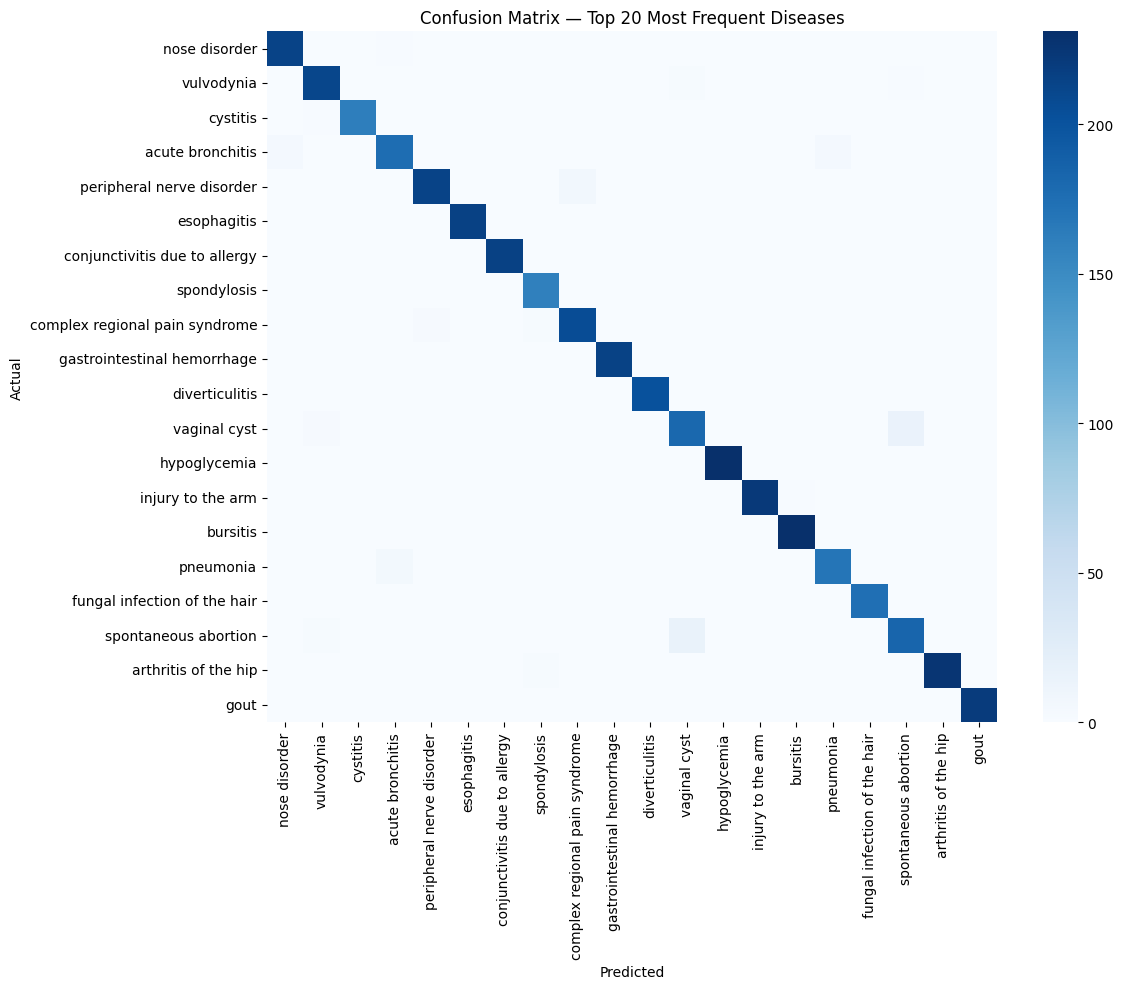

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

test_label_counts = pd.Series(true_labels).value_counts()
top_20_labels     = test_label_counts.head(20).index

mask         = np.isin(true_labels, top_20_labels)
filtered_true = true_labels[mask]
filtered_pred = pred_labels[mask]

cm_top20 = confusion_matrix(filtered_true, filtered_pred, labels=top_20_labels)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_top20, annot=False, cmap="Blues",
    xticklabels=[id2label[i] for i in top_20_labels],
    yticklabels=[id2label[i] for i in top_20_labels]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Top 20 Most Frequent Diseases")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Inference Function

Self-contained — loads model from disk, doesn't rely on `trainer` object.

In [23]:
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast
import torch
import numpy as np

MODEL_PATH = OUTPUT_DIR  # "./zolex_disease_model_v2"

# Load model + tokenizer from disk (works after kernel restart)
_infer_tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_PATH)
_infer_model     = DistilBertForSequenceClassification.from_pretrained(MODEL_PATH)
_infer_device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_infer_model.to(_infer_device)
_infer_model.eval()

print(f"Inference model loaded on {_infer_device}")


def predict(text, top_k=3):
   
    inputs = _infer_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH
    )
    inputs = {k: v.to(_infer_device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = _infer_model(**inputs)
        probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

    top_k_idx = np.argsort(probs)[-top_k:][::-1]

    return [
        {"disease": _infer_model.config.id2label[int(idx)],
         "confidence": float(probs[idx])}
        for idx in top_k_idx
    ]


# Quick test
test_text = "Patient has fever, cough, and difficulty breathing"
results   = predict(test_text)
print(f"\nInput: '{test_text}'")
for r in results:
    print(f"  {r['disease']:<50} {r['confidence']:.4f}")

Inference model loaded on cuda

Input: 'Patient has fever, cough, and difficulty breathing'
  asthma                                             0.2463
  acute bronchospasm                                 0.2041
  acute respiratory distress syndrome (ards)         0.1825


## Batch Inference Examples

In [24]:
test_cases = [
    "Patient has cough, pain in testicles, abnormal appearing skin, fever, itching of skin.",
    "chest pain and shortness of breath",
    "itchy skin with red rash",
    "frequent urination and high blood sugar",
    "severe headache and sensitivity to light",
    "fever, chills, sweating, headache, muscle aches, nausea, and fatigue",
]

print("=" * 70)
for text in test_cases:
    print(f"\n🔍 Input: {text}")
    results = predict(text, top_k=3)
    for i, r in enumerate(results, 1):
        print(f"   {i}. {r['disease']:<50} ({r['confidence']*100:.1f}%)")
print("=" * 70)


🔍 Input: Patient has cough, pain in testicles, abnormal appearing skin, fever, itching of skin.
   1. chickenpox                                         (99.2%)
   2. male genitalia infection                           (0.2%)
   3. impetigo                                           (0.1%)

🔍 Input: chest pain and shortness of breath
   1. magnesium deficiency                               (11.9%)
   2. hypocalcemia                                       (7.3%)
   3. aortic valve disease                               (6.2%)

🔍 Input: itchy skin with red rash
   1. fungal infection of the skin                       (57.1%)
   2. itching of unknown cause                           (8.5%)
   3. fungal infection of the hair                       (5.8%)

🔍 Input: frequent urination and high blood sugar
   1. prostatitis                                        (16.4%)
   2. urinary tract obstruction                          (10.2%)
   3. atrial flutter                                     (7.6%)
